# Notebook 3 — Controlling for confounders

Notebook 2 found that `crm_usage` has the strongest naive correlation with revenue — stronger even than `demos_given` and `proposals_sent`. Before believing "logging more in the CRM drives sales," we should ask: could that correlation be explained by something else entirely — say, the quality of the territory a rep was handed — rather than any real link between CRM usage and revenue?

- **Part A** builds the tool for answering that — controlling for a third variable — on a classic toy example that has nothing to do with sales.
- **Part B** applies it to `sales_activity_data.csv`, controlling for `territory_score`, and checks which activities' correlations survive.

Still no peeking at `ground_truth.json`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e5e0", "axes.edgecolor": "#c9c8c0"})

ACCENT = "#2a78d6"
NEUTRAL = "#9a9990"
NEGATIVE = "#e34948"
BAND_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]  # first three categorical slots, safe as a group

DATA_DIR = Path("../data")
rng = np.random.default_rng(37)

## Part A — A classic confound: ice cream and drownings

Across many towns, on many different days, ice cream sales and drowning incidents are strongly correlated. Buying more ice cream doesn't cause anyone to drown, and drownings don't cause ice cream sales. Both are driven by a third variable: **temperature**. Hot days mean more ice cream *and* more people swimming (and so more drownings) — with no direct link between the two at all.

We'll simulate exactly that structure: temperature drives both variables independently, and there is no ice-cream-to-drowning link anywhere in how we generate the data.

In [2]:
n_days = 150
temperature = rng.normal(75, 10, n_days)  # degrees F, the confounder

ice_cream_sales = 5 * temperature + rng.normal(0, 35, n_days)   # driven by temperature only
drownings = 0.3 * temperature + rng.normal(0, 2, n_days)         # driven by temperature only, independently

toy = pd.DataFrame({"temperature": temperature, "ice_cream_sales": ice_cream_sales, "drownings": drownings})
toy.head()

,temperature,ice_cream_sales,drownings
0,83.999031,413.380821,28.561456
1,70.416247,380.958374,20.286057
2,61.859146,329.088076,18.769286
3,81.586977,473.762092,22.424110
4,84.554259,446.836367,25.410777


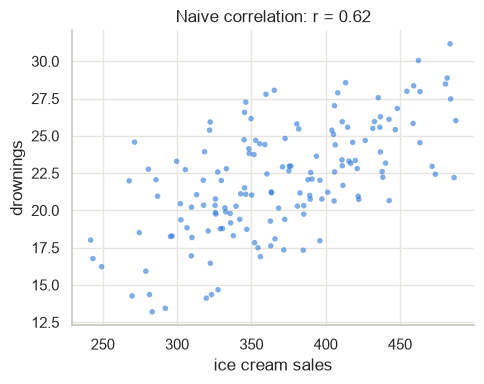

r(ice cream, drownings) = 0.6240  — looks like a strong relationship


In [3]:
r_naive = stats.pearsonr(ice_cream_sales, drownings).statistic

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(ice_cream_sales, drownings, s=16, alpha=0.6, color=ACCENT, edgecolor="none")
ax.set_xlabel("ice cream sales")
ax.set_ylabel("drownings")
ax.set_title(f"Naive correlation: r = {r_naive:.2f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"r(ice cream, drownings) = {r_naive:.4f}  — looks like a strong relationship")

Before any formula: what happens if we only compare days with *similar* temperature to each other? Split the days into three temperature bands (cool / mild / hot) and color by band.

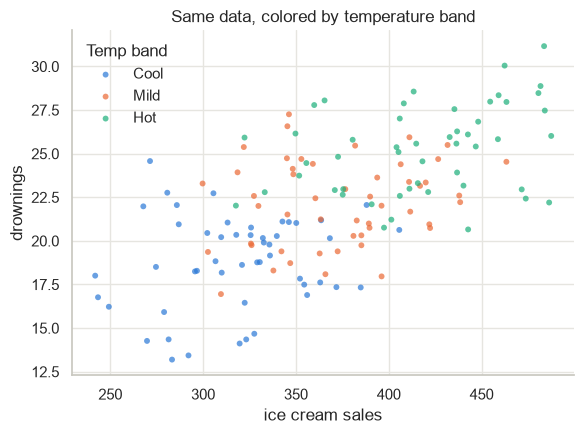

In [4]:
toy["temp_band"] = pd.qcut(toy["temperature"], 3, labels=["Cool", "Mild", "Hot"])

fig, ax = plt.subplots(figsize=(6, 4.5))
for band, color in zip(["Cool", "Mild", "Hot"], BAND_COLORS):
    subset = toy[toy["temp_band"] == band]
    ax.scatter(subset["ice_cream_sales"], subset["drownings"], s=18, alpha=0.7, color=color, edgecolor="none", label=band)
ax.set_xlabel("ice cream sales")
ax.set_ylabel("drownings")
ax.set_title("Same data, colored by temperature band")
ax.legend(title="Temp band", frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Look within a single color: the cool days form their own little cloud, and inside that cloud there's no visible slope — same for mild and hot. The overall trend only appears because the three clouds sit at different heights along both axes (hot days have both more ice cream sold and more drownings). The "relationship" is really three flat, unrelated clusters, stacked diagonally by temperature.

**Controlling for a confounder means formalizing exactly this: asking what the X-Y relationship looks like once you've accounted for Z.**

## Partial correlation, step by step

The three-band picture is convincing but coarse — 3 bands is a rough way to "hold temperature constant." Partial correlation does the same thing exactly, using every point:

1. Predict ice cream sales **from temperature alone** (a simple regression line). Subtract that prediction from the real values. What's left over — the **residual** — is "ice cream sales, with everything temperature explains removed."
2. Do the same for drownings: predict drownings from temperature, subtract, keep the residual.
3. Correlate the two sets of residuals. Since both have had temperature's influence stripped out, whatever correlation remains **can't be coming from temperature** — it's whatever direct relationship (if any) is left between ice cream sales and drownings themselves.

### Step 1 — how is each variable related to temperature, on its own?

Before we can remove temperature's influence, we need to know what that influence actually looks like: fit a straight line predicting ice cream sales from temperature alone, and separately, a straight line predicting drownings from temperature alone.

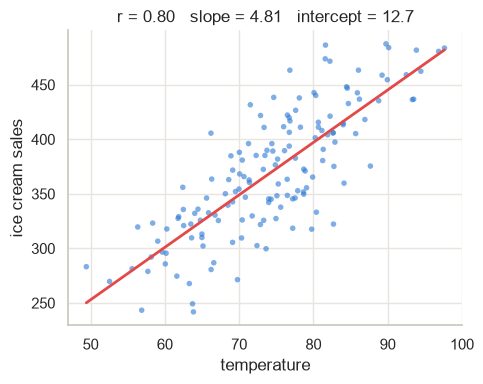

ice cream sales ≈ 12.7 + 4.81 × temperature   (r = 0.7985)


In [5]:
fit_ice = stats.linregress(temperature, ice_cream_sales)
r_xz = fit_ice.rvalue

order = np.argsort(temperature)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(temperature, ice_cream_sales, s=16, alpha=0.6, color=ACCENT, edgecolor="none")
ax.plot(temperature[order], fit_ice.intercept + fit_ice.slope * temperature[order], color=NEGATIVE, linewidth=2)
ax.set_xlabel("temperature")
ax.set_ylabel("ice cream sales")
ax.set_title(f"r = {r_xz:.2f}   slope = {fit_ice.slope:.2f}   intercept = {fit_ice.intercept:.1f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"ice cream sales ≈ {fit_ice.intercept:.1f} + {fit_ice.slope:.2f} × temperature   (r = {r_xz:.4f})")

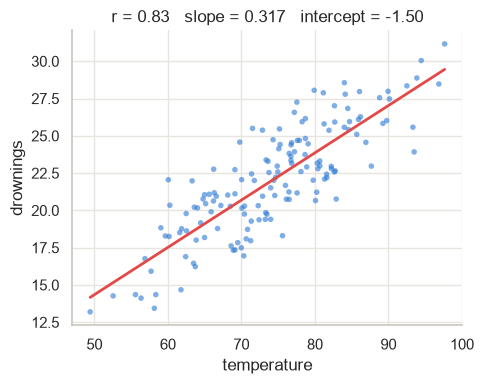

drownings ≈ -1.50 + 0.317 × temperature   (r = 0.8316)


In [6]:
fit_drown = stats.linregress(temperature, drownings)
r_yz = fit_drown.rvalue

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(temperature, drownings, s=16, alpha=0.6, color=ACCENT, edgecolor="none")
ax.plot(temperature[order], fit_drown.intercept + fit_drown.slope * temperature[order], color=NEGATIVE, linewidth=2)
ax.set_xlabel("temperature")
ax.set_ylabel("drownings")
ax.set_title(f"r = {r_yz:.2f}   slope = {fit_drown.slope:.3f}   intercept = {fit_drown.intercept:.2f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"drownings ≈ {fit_drown.intercept:.2f} + {fit_drown.slope:.3f} × temperature   (r = {r_yz:.4f})")

### Step 2 — subtract the line's prediction, keep what's left

For every day, the red line above gives a prediction — "what temperature alone says ice cream sales should be." The residual is just actual minus predicted: how far each real point sits above or below the line.

In [7]:
predicted_ice = fit_ice.intercept + fit_ice.slope * temperature
resid_ice_manual = ice_cream_sales - predicted_ice

ice_steps = pd.DataFrame({
    "temperature": temperature,
    "actual ice cream sales": ice_cream_sales,
    "predicted (from temp alone)": predicted_ice,
    "residual = actual - predicted": resid_ice_manual,
}).head(8)
ice_steps

,temperature,actual ice cream sales,predicted (from temp alone),residual = actual - predicted
0,83.999031,413.380821,416.380244,-2.999423
1,70.416247,380.958374,351.103118,29.855257
2,61.859146,329.088076,309.978783,19.109293
3,81.586977,473.762092,404.788219,68.973873
4,84.554259,446.836367,419.048597,27.787770
5,80.246310,401.370519,398.345147,3.025372
6,49.417306,283.248752,250.184885,33.063867
7,59.646588,296.673849,299.345508,-2.671659


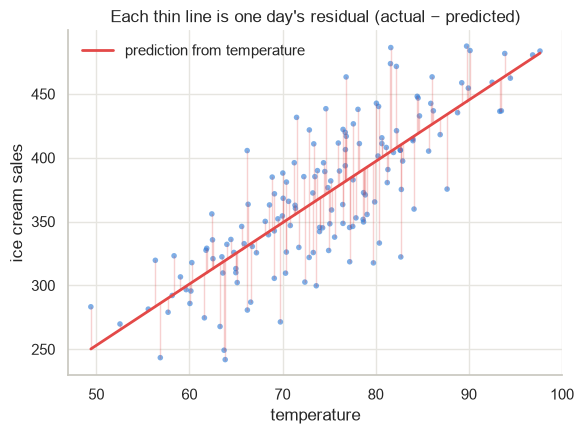

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(temperature, ice_cream_sales, s=16, alpha=0.6, color=ACCENT, edgecolor="none")
ax.plot(temperature[order], predicted_ice[order], color=NEGATIVE, linewidth=2, label="prediction from temperature")
for xi, yi, ypi in zip(temperature, ice_cream_sales, predicted_ice):
    ax.plot([xi, xi], [ypi, yi], color=NEGATIVE, alpha=0.25, linewidth=1)
ax.set_xlabel("temperature")
ax.set_ylabel("ice cream sales")
ax.set_title("Each thin line is one day's residual (actual − predicted)")
ax.legend(frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
predicted_drown = fit_drown.intercept + fit_drown.slope * temperature
resid_drown_manual = drownings - predicted_drown

drown_steps = pd.DataFrame({
    "temperature": temperature,
    "actual drownings": drownings,
    "predicted (from temp alone)": predicted_drown,
    "residual = actual - predicted": resid_drown_manual,
}).head(8)
drown_steps

,temperature,actual drownings,predicted (from temp alone),residual = actual - predicted
0,83.999031,28.561456,25.128258,3.433198
1,70.416247,20.286057,20.821625,-0.535568
2,61.859146,18.769286,18.108463,0.660823
3,81.586977,22.424110,24.363478,-1.939368
4,84.554259,25.410777,25.304301,0.106476
5,80.246310,21.216988,23.938399,-2.721411
6,49.417306,13.193490,14.163584,-0.970094
7,59.646588,18.284623,17.406937,0.877685


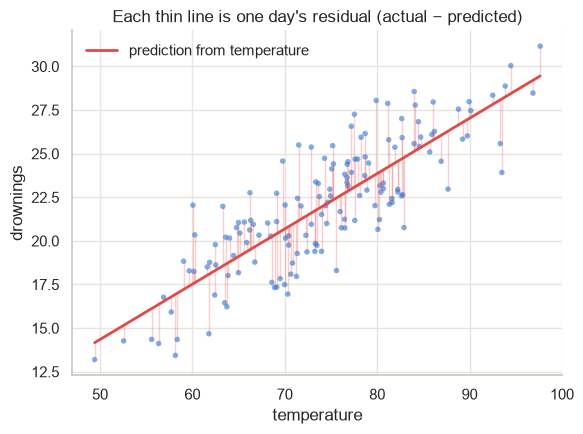

In [10]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(temperature, drownings, s=16, alpha=0.6, color=ACCENT, edgecolor="none")
ax.plot(temperature[order], predicted_drown[order], color=NEGATIVE, linewidth=2, label="prediction from temperature")
for xi, yi, ypi in zip(temperature, drownings, predicted_drown):
    ax.plot([xi, xi], [ypi, yi], color=NEGATIVE, alpha=0.25, linewidth=1)
ax.set_xlabel("temperature")
ax.set_ylabel("drownings")
ax.set_title("Each thin line is one day's residual (actual − predicted)")
ax.legend(frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### Step 3 — package it, and correlate the two sets of leftovers

We just computed residuals by hand, one variable at a time. Wrapping that into a small reusable function (it's the same three lines: fit a line on `z`, predict, subtract) lets us apply it to both variables at once — and to any other pair, later.

In [11]:
def residualize(values, z):
    """Return `values` with everything a straight-line fit on z explains removed."""
    fit = stats.linregress(z, values)
    predicted = fit.slope * z + fit.intercept
    return values - predicted

resid_ice_cream = residualize(ice_cream_sales, temperature)
resid_drownings = residualize(drownings, temperature)

print("matches the by-hand residuals above:")
print("  ice cream:", np.allclose(resid_ice_cream, resid_ice_manual))
print("  drownings:", np.allclose(resid_drownings, resid_drown_manual))

matches the by-hand residuals above:
  ice cream: True
  drownings: True


This is the actual diagram partial correlation is computed from — not the raw ice cream/drownings scatter from before, but the two **leftover** series plotted against each other. Whatever pattern (or lack of one) shows up here, after temperature has been subtracted out of both, is exactly what `stats.pearsonr(resid_ice_cream, resid_drownings)` measures.

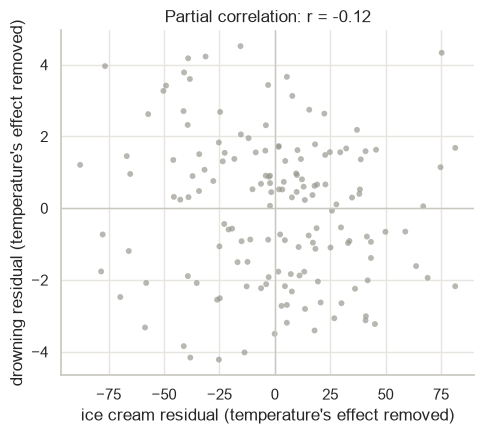

In [12]:
r_partial_preview = stats.pearsonr(resid_ice_cream, resid_drownings).statistic

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.axhline(0, color="#c9c8c0", linewidth=1)
ax.axvline(0, color="#c9c8c0", linewidth=1)
ax.scatter(resid_ice_cream, resid_drownings, s=18, alpha=0.7, color=NEUTRAL, edgecolor="none")
ax.set_xlabel("ice cream residual (temperature's effect removed)")
ax.set_ylabel("drowning residual (temperature's effect removed)")
ax.set_title(f"Partial correlation: r = {r_partial_preview:.2f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
r_partial_by_hand, p_partial_by_hand = stats.pearsonr(resid_ice_cream, resid_drownings)

# independent check: the standard closed-form partial correlation formula
r_xy = stats.pearsonr(ice_cream_sales, drownings).statistic
r_xz = stats.pearsonr(ice_cream_sales, temperature).statistic
r_yz = stats.pearsonr(drownings, temperature).statistic
r_partial_formula = (r_xy - r_xz * r_yz) / np.sqrt((1 - r_xz**2) * (1 - r_yz**2))

print(f"naive r(ice cream, drownings)                = {r_xy:.4f}")
print(f"partial r, via residuals                     = {r_partial_by_hand:.4f}  (p = {p_partial_by_hand:.3f})")
print(f"partial r, via closed-form formula            = {r_partial_formula:.4f}")

naive r(ice cream, drownings)                = 0.6240
partial r, via residuals                     = -0.1200  (p = 0.144)
partial r, via closed-form formula            = -0.1200


### What that formula is actually doing

The closed-form formula gets the same answer without ever computing a residual — it's built entirely from the three pairwise correlations above:

- **`r_xz × r_yz`** estimates how correlated ice cream and drownings *would look purely because both are tied to temperature*, even with zero direct connection between them — ice cream relates to temperature by 0.80, drownings by 0.83, so temperature alone could produce roughly `0.80 × 0.83` worth of X-Y correlation "by relay."
- **`r_xy − r_xz×r_yz`** subtracts that relayed-through-temperature portion out of the naive correlation, leaving whatever's left that temperature doesn't explain.
- **`√((1−r_xz²)(1−r_yz²))`** rescales that leftover back onto a proper -1-to-+1 scale. `r²` is the fraction of a variable's variance explained by the other, so `1 − r_xz²` is exactly the fraction of ice cream's spread left in its residual (same idea as the "leftover" table from Step 2) — and residualizing shrinks each variable's spread, so dividing by these shrunk amounts is what puts the answer back on the normal correlation scale.

In [14]:
relay_term = r_xz * r_yz
numerator = r_xy - relay_term
denominator = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))

print(f"r_xy = {r_xy:.4f}   (ice cream vs. drownings, naive)")
print(f"r_xz = {r_xz:.4f}   (ice cream vs. temperature)")
print(f"r_yz = {r_yz:.4f}   (drownings vs. temperature)")
print()
print(f"relay term:    r_xz * r_yz          = {r_xz:.4f} * {r_yz:.4f} = {relay_term:.4f}")
print(f"numerator:     r_xy - relay term     = {r_xy:.4f} - {relay_term:.4f} = {numerator:.4f}")
print(f"denominator:   sqrt((1-r_xz^2)(1-r_yz^2)) = sqrt({1 - r_xz**2:.4f} * {1 - r_yz**2:.4f}) = {denominator:.4f}")
print()
print(f"r_partial = numerator / denominator = {numerator:.4f} / {denominator:.4f} = {numerator / denominator:.4f}")

r_xy = 0.6240   (ice cream vs. drownings, naive)
r_xz = 0.7985   (ice cream vs. temperature)
r_yz = 0.8316   (drownings vs. temperature)

relay term:    r_xz * r_yz          = 0.7985 * 0.8316 = 0.6641
numerator:     r_xy - relay term     = 0.6240 - 0.6641 = -0.0401
denominator:   sqrt((1-r_xz^2)(1-r_yz^2)) = sqrt(0.3624 * 0.3084) = 0.3343

r_partial = numerator / denominator = -0.0401 / 0.3343 = -0.1200


## The same question, asked with multiple regression

Partial correlation and multiple regression are two routes to the same place. Below, we build up what "regression with two predictors" actually means, slowly, before looking at any coefficient table.

### From a line to a plane

Every `stats.linregress(z, values)` call so far has fit a **line**: one predictor (temperature) on one axis, one outcome on the other, and the line's slope says how much the outcome changes per unit of the predictor. That's regression with one predictor.

`drownings ~ ice_cream_sales + temperature` uses **two** predictors at once. Instead of a 2D scatter (one predictor vs. one outcome), the data now lives in 3D: ice cream sales on one axis, temperature on another, drownings on the vertical axis. One point per day. Instead of fitting the best straight line through a 2D cloud, we're fitting the best flat **plane** through this 3D cloud — same idea (minimize the total squared vertical distance from each point to the surface), just one dimension higher.

First, just the raw data, no fitting yet:

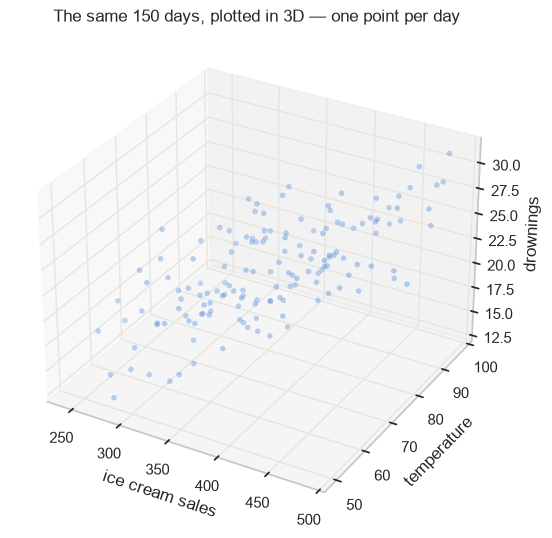

In [15]:
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ice_cream_sales, temperature, drownings, s=16, alpha=0.6, color=ACCENT, edgecolor="none")
ax.set_xlabel("ice cream sales")
ax.set_ylabel("temperature")
ax.set_zlabel("drownings")
ax.set_title("The same 150 days, plotted in 3D — one point per day")
plt.tight_layout()
plt.show()

### Fit the plane

`sm.OLS` finds the flattest plane through that cloud — the one equation `drownings ≈ b0 + b1×ice_cream_sales + b2×temperature` that minimizes total squared error, across all 150 points at once. `b1` and `b2` are the plane's tilt along each axis.

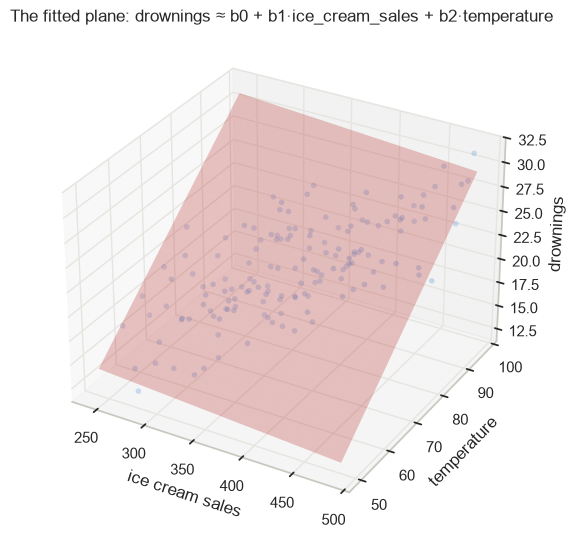

b0 (intercept)          = -1.416
b1 (ice_cream_sales)    = -0.0070
b2 (temperature)        = 0.3508


In [16]:
X = sm.add_constant(pd.DataFrame({"ice_cream_sales": ice_cream_sales, "temperature": temperature}))
model = sm.OLS(drownings, X).fit()
b0, b1, b2 = model.params["const"], model.params["ice_cream_sales"], model.params["temperature"]

ice_grid, temp_grid = np.meshgrid(
    np.linspace(ice_cream_sales.min(), ice_cream_sales.max(), 15),
    np.linspace(temperature.min(), temperature.max(), 15),
)
predicted_grid = b0 + b1 * ice_grid + b2 * temp_grid

fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ice_cream_sales, temperature, drownings, s=16, alpha=0.5, color=ACCENT, edgecolor="none")
ax.plot_surface(ice_grid, temp_grid, predicted_grid, color=NEGATIVE, alpha=0.3, edgecolor="none")
ax.set_xlabel("ice cream sales")
ax.set_ylabel("temperature")
ax.set_zlabel("drownings")
ax.set_title("The fitted plane: drownings ≈ b0 + b1·ice_cream_sales + b2·temperature")
plt.tight_layout()
plt.show()

print(f"b0 (intercept)          = {b0:.3f}")
print(f"b1 (ice_cream_sales)    = {b1:.4f}")
print(f"b2 (temperature)        = {b2:.4f}")

### What the plane's tilt actually means

`b1`, the coefficient on `ice_cream_sales`, is the plane's slope *along the ice-cream axis, at any fixed temperature*. Picture slicing straight through the plane at one exact temperature value, like cutting a piece of paper straight up and down: that slice is a straight line, and its slope is `b1`. Slice the plane again at a different fixed temperature, and you get a different straight line, parallel to the first one, but shifted up or down — same slope `b1`, because that's the one slope the plane uses at every temperature.

This is exactly the three-band picture from Part A, made precise. Cool/Mild/Hot were three coarse slices of temperature; within each, there was no visible slope. The plane's `b1` is that same "slope within a fixed temperature" idea, just computed as one consistent number across every temperature instead of three rough bins. Let's slice the actual fitted plane at each band's temperature and overlay those slices on the original band-colored scatter:

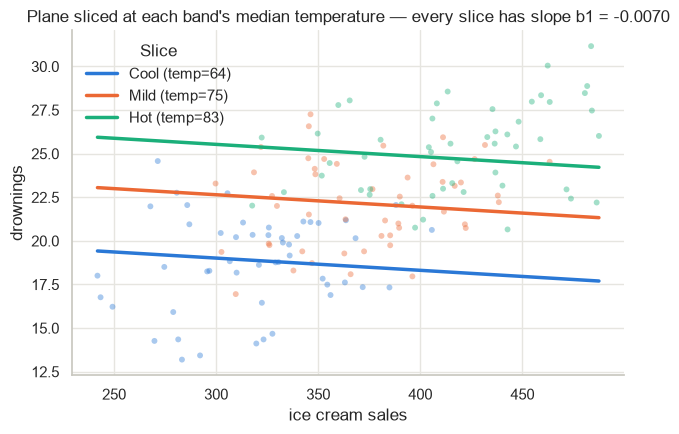

In [17]:
band_median_temp = toy.groupby("temp_band", observed=True)["temperature"].median()
ice_range = np.linspace(ice_cream_sales.min(), ice_cream_sales.max(), 50)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for band, color in zip(["Cool", "Mild", "Hot"], BAND_COLORS):
    subset = toy[toy["temp_band"] == band]
    ax.scatter(subset["ice_cream_sales"], subset["drownings"], s=18, alpha=0.4, color=color, edgecolor="none")
    fixed_temp = band_median_temp[band]
    slice_line = b0 + b1 * ice_range + b2 * fixed_temp
    ax.plot(ice_range, slice_line, color=color, linewidth=2.5, label=f"{band} (temp={fixed_temp:.0f})")
ax.set_xlabel("ice cream sales")
ax.set_ylabel("drownings")
ax.set_title(f"Plane sliced at each band's median temperature — every slice has slope b1 = {b1:.4f}")
ax.legend(frameon=False, title="Slice")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Flat, near-identical slices — visually, `b1` looks like it's ~0. The regression output below gives the actual number for `b1`, plus a standard error and p-value telling us whether that near-zero slope is distinguishable from pure noise.

In [18]:
model.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,-1.415952,1.300320,-1.088925,2.779687e-01,-3.985688,1.153784
ice_cream_sales,-0.007012,0.004785,-1.465301,1.449744e-01,-0.016468,0.002445
temperature,0.350762,0.028799,12.179588,4.933009e-24,0.293848,0.407676


`ice_cream_sales`'s coefficient (b1 ≈ -0.007) says: among days with the *same* temperature, one more unit of ice cream sold predicts essentially no change in drownings — and its p-value (0.145) says that tiny slope isn't distinguishable from zero. `temperature`'s coefficient, by contrast, is large and highly significant (p ≈ 5×10⁻²⁴).

So the regression agrees with the residual method and the slice plot: once temperature is accounted for, ice cream sales tells you nothing about drownings. Three routes — residualize-and-correlate, the closed-form formula, and fit-a-plane-and-read-b1 — all answer the same question and land in the same place.

## Part B — Applying this to the sales activity data

Same method, same `sales_activity_data.csv`. For each activity, we'll compute its naive correlation with revenue (as in notebook 2) and its partial correlation controlling for `territory_score`, side by side.

### Worked example: `demos_given`, by hand

Before running this on all 5 activities at once, let's work through one — `demos_given` — exactly the way we worked through ice cream and drownings, so the calculation is visible on real data, not just the toy example.

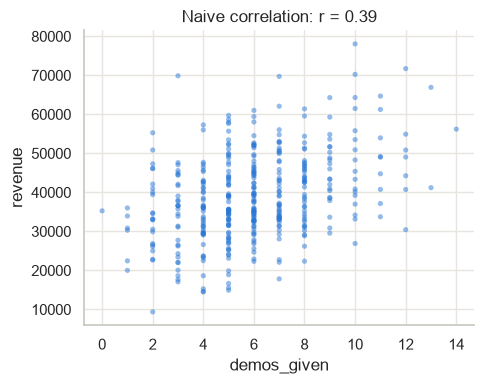

r(demos_given, revenue) = 0.3860


In [19]:
df = pd.read_csv(DATA_DIR / "sales_activity_data.csv")
activity_cols = ["demos_given", "proposals_sent", "crm_usage", "calls_made", "training_completed"]

r_xy_demos = stats.pearsonr(df["demos_given"], df["revenue"]).statistic

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(df["demos_given"], df["revenue"], s=14, alpha=0.5, color=ACCENT, edgecolor="none")
ax.set_xlabel("demos_given")
ax.set_ylabel("revenue")
ax.set_title(f"Naive correlation: r = {r_xy_demos:.2f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"r(demos_given, revenue) = {r_xy_demos:.4f}")

**Step 1 — how is each variable related to territory, on its own?** Same as with temperature before: fit a line predicting `demos_given` from `territory_score` alone, and separately, a line predicting `revenue` from `territory_score` alone.

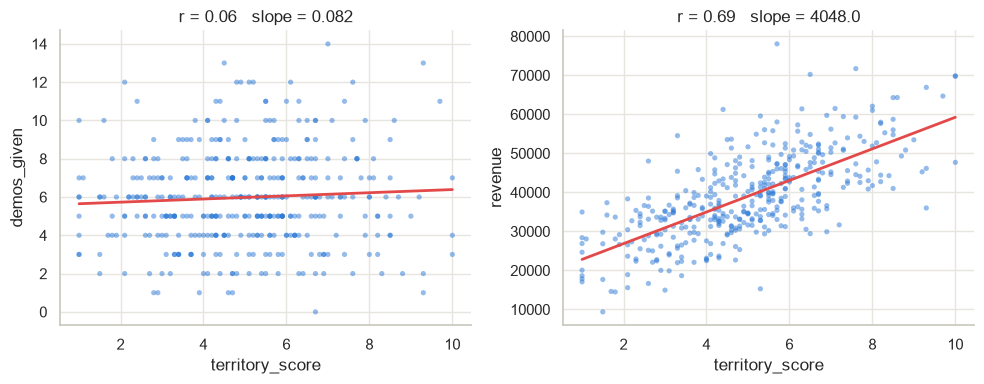

demos_given ≈ 5.57 + 0.082 × territory_score   (r_xz = 0.0628)
revenue     ≈ 18765.5 + 4048.0 × territory_score   (r_yz = 0.6927)


In [20]:
fit_demos_terr = stats.linregress(df["territory_score"], df["demos_given"])
fit_rev_terr = stats.linregress(df["territory_score"], df["revenue"])
r_xz_demos = fit_demos_terr.rvalue
r_yz_demos = fit_rev_terr.rvalue

terr_order = np.argsort(df["territory_score"].to_numpy())
terr_sorted = df["territory_score"].to_numpy()[terr_order]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df["territory_score"], df["demos_given"], s=14, alpha=0.5, color=ACCENT, edgecolor="none")
axes[0].plot(terr_sorted, fit_demos_terr.intercept + fit_demos_terr.slope * terr_sorted, color=NEGATIVE, linewidth=2)
axes[0].set_xlabel("territory_score")
axes[0].set_ylabel("demos_given")
axes[0].set_title(f"r = {r_xz_demos:.2f}   slope = {fit_demos_terr.slope:.3f}")

axes[1].scatter(df["territory_score"], df["revenue"], s=14, alpha=0.5, color=ACCENT, edgecolor="none")
axes[1].plot(terr_sorted, fit_rev_terr.intercept + fit_rev_terr.slope * terr_sorted, color=NEGATIVE, linewidth=2)
axes[1].set_xlabel("territory_score")
axes[1].set_ylabel("revenue")
axes[1].set_title(f"r = {r_yz_demos:.2f}   slope = {fit_rev_terr.slope:.1f}")

for ax in axes:
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"demos_given ≈ {fit_demos_terr.intercept:.2f} + {fit_demos_terr.slope:.3f} × territory_score   (r_xz = {r_xz_demos:.4f})")
print(f"revenue     ≈ {fit_rev_terr.intercept:.1f} + {fit_rev_terr.slope:.1f} × territory_score   (r_yz = {r_yz_demos:.4f})")

**Step 2 — subtract each prediction, keep what's left.** Using the same `residualize()` function from Part A: reps' `demos_given` with territory's influence removed, and revenue with territory's influence removed.

In [21]:
resid_demos = residualize(df["demos_given"].to_numpy(), df["territory_score"].to_numpy())
resid_revenue_demos = residualize(df["revenue"].to_numpy(), df["territory_score"].to_numpy())

demos_steps = pd.DataFrame({
    "territory_score": df["territory_score"],
    "actual demos_given": df["demos_given"],
    "demos_given residual": resid_demos,
    "actual revenue": df["revenue"],
    "revenue residual": resid_revenue_demos,
}).head(8)
demos_steps

,territory_score,actual demos_given,demos_given residual,actual revenue,revenue residual
0,5.6,5,-1.027209,34080.66,-7353.860834
1,2.9,1,-4.805001,20011.97,-10492.866194
2,6.5,8,1.898722,47631.93,2554.180952
3,6.9,3,-3.134197,36598.13,-10098.831587
4,1.1,7,1.343137,28062.03,4843.650232
5,2.4,5,-0.763852,31477.00,2996.179480
6,5.3,4,-2.002519,40177.95,-42.161430
7,4.4,9,3.071550,42012.68,5435.796783


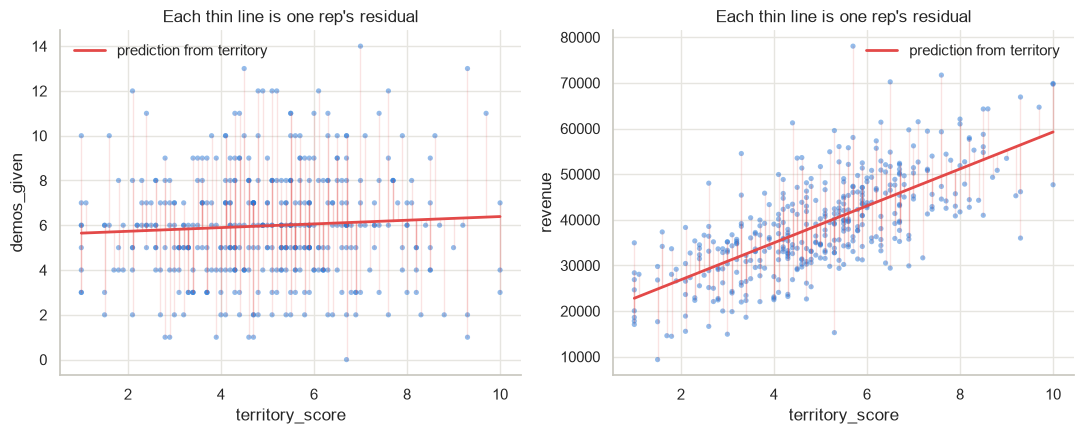

In [22]:
predicted_demos = fit_demos_terr.intercept + fit_demos_terr.slope * df["territory_score"].to_numpy()
predicted_revenue_demos = fit_rev_terr.intercept + fit_rev_terr.slope * df["territory_score"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(df["territory_score"], df["demos_given"], s=14, alpha=0.5, color=ACCENT, edgecolor="none")
axes[0].plot(terr_sorted, fit_demos_terr.intercept + fit_demos_terr.slope * terr_sorted, color=NEGATIVE, linewidth=2, label="prediction from territory")
for xi, yi, ypi in zip(df["territory_score"], df["demos_given"], predicted_demos):
    axes[0].plot([xi, xi], [ypi, yi], color=NEGATIVE, alpha=0.15, linewidth=1)
axes[0].set_xlabel("territory_score")
axes[0].set_ylabel("demos_given")
axes[0].set_title("Each thin line is one rep's residual")
axes[0].legend(frameon=False)

axes[1].scatter(df["territory_score"], df["revenue"], s=14, alpha=0.5, color=ACCENT, edgecolor="none")
axes[1].plot(terr_sorted, fit_rev_terr.intercept + fit_rev_terr.slope * terr_sorted, color=NEGATIVE, linewidth=2, label="prediction from territory")
for xi, yi, ypi in zip(df["territory_score"], df["revenue"], predicted_revenue_demos):
    axes[1].plot([xi, xi], [ypi, yi], color=NEGATIVE, alpha=0.15, linewidth=1)
axes[1].set_xlabel("territory_score")
axes[1].set_ylabel("revenue")
axes[1].set_title("Each thin line is one rep's residual")
axes[1].legend(frameon=False)

for ax in axes:
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Step 3 — correlate the two sets of leftovers.** Same diagram as the ice cream/drownings case: this scatter of residual vs. residual is exactly what the partial correlation is computed from.

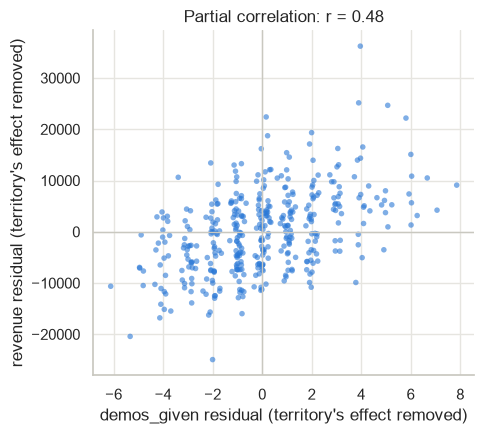

partial r(demos_given, revenue | territory) = 0.4758  (p = 5.47e-24)


In [23]:
r_partial_demos, p_partial_demos = stats.pearsonr(resid_demos, resid_revenue_demos)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.axhline(0, color="#c9c8c0", linewidth=1)
ax.axvline(0, color="#c9c8c0", linewidth=1)
ax.scatter(resid_demos, resid_revenue_demos, s=16, alpha=0.6, color=ACCENT, edgecolor="none")
ax.set_xlabel("demos_given residual (territory's effect removed)")
ax.set_ylabel("revenue residual (territory's effect removed)")
ax.set_title(f"Partial correlation: r = {r_partial_demos:.2f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"partial r(demos_given, revenue | territory) = {r_partial_demos:.4f}  (p = {p_partial_demos:.2e})")

And the same closed-form formula check as before, using the three pairwise correlations we already computed above:

In [24]:
relay_term_demos = r_xz_demos * r_yz_demos
numerator_demos = r_xy_demos - relay_term_demos
denominator_demos = np.sqrt((1 - r_xz_demos**2) * (1 - r_yz_demos**2))
r_partial_formula_demos = numerator_demos / denominator_demos

print(f"r_xy = {r_xy_demos:.4f}   (demos_given vs. revenue, naive)")
print(f"r_xz = {r_xz_demos:.4f}   (demos_given vs. territory_score)")
print(f"r_yz = {r_yz_demos:.4f}   (revenue vs. territory_score)")
print()
print(f"relay term:  r_xz * r_yz = {r_xz_demos:.4f} * {r_yz_demos:.4f} = {relay_term_demos:.4f}")
print(f"numerator:   r_xy - relay term = {r_xy_demos:.4f} - {relay_term_demos:.4f} = {numerator_demos:.4f}")
print(f"denominator: sqrt((1-r_xz^2)(1-r_yz^2)) = {denominator_demos:.4f}")
print()
print(f"r_partial (formula)  = {r_partial_formula_demos:.4f}")
print(f"r_partial (residuals) = {r_partial_demos:.4f}")

r_xy = 0.3860   (demos_given vs. revenue, naive)
r_xz = 0.0628   (demos_given vs. territory_score)
r_yz = 0.6927   (revenue vs. territory_score)

relay term:  r_xz * r_yz = 0.0628 * 0.6927 = 0.0435
numerator:   r_xy - relay term = 0.3860 - 0.0435 = 0.3425
denominator: sqrt((1-r_xz^2)(1-r_yz^2)) = 0.7198

r_partial (formula)  = 0.4758
r_partial (residuals) = 0.4758


`demos_given`'s correlation with revenue went **up**, not down, once territory is controlled for (naive r ≈ 0.39 → partial r ≈ 0.48) — the opposite of what happened to `crm_usage` two sections ago. That's not a mistake: `demos_given` barely relates to territory (r_xz is small), so there's little "relay" to subtract, while territory does explain a real chunk of revenue's spread. Removing that chunk shrinks revenue's leftover noise, and the real demos-to-revenue relationship stands out more clearly against a quieter background. Now let's run this same three-step calculation on all 5 activities at once.

In [25]:
def partial_corr_with_pvalue(x, y, z):
    resid_x = residualize(x.to_numpy(), z.to_numpy())
    resid_y = residualize(y.to_numpy(), z.to_numpy())
    r, p = stats.pearsonr(resid_x, resid_y)
    return r, p

rows = []
for col in activity_cols:
    naive_r, naive_p = stats.pearsonr(df[col], df["revenue"])
    adj_r, adj_p = partial_corr_with_pvalue(df[col], df["revenue"], df["territory_score"])
    rows.append({
        "activity": col,
        "naive_r": naive_r,
        "naive_p": naive_p,
        "partial_r (controlling for territory)": adj_r,
        "partial_p": adj_p,
    })

adjustment_table = pd.DataFrame(rows).sort_values("naive_r", key=abs, ascending=False).reset_index(drop=True)
adjustment_table

,activity,naive_r,naive_p,partial_r (controlling for territory),partial_p
0,crm_usage,0.610302,3.498339e-42,0.020617,6.810081e-01
1,proposals_sent,0.419147,1.892375e-18,0.630669,9.481739e-46
2,calls_made,0.406143,2.560032e-17,0.357679,1.623360e-13
3,demos_given,0.385986,1.165936e-15,0.475793,5.467925e-24
4,training_completed,0.034536,4.909695e-01,-0.007120,8.871097e-01


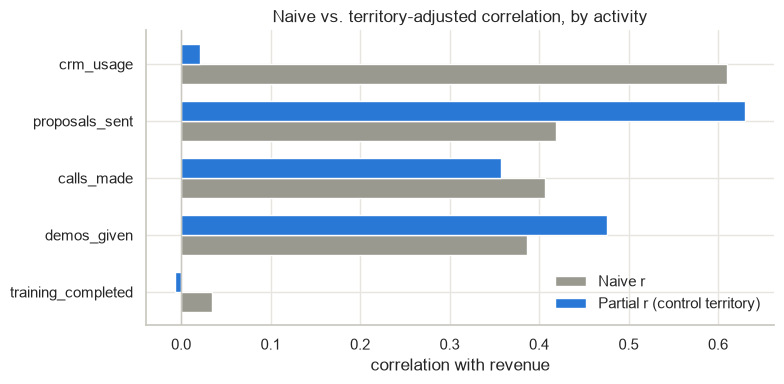

In [26]:
plot_order = adjustment_table.sort_values("naive_r")["activity"]
x_pos = np.arange(len(plot_order))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
naive_vals = adjustment_table.set_index("activity").loc[plot_order, "naive_r"]
partial_vals = adjustment_table.set_index("activity").loc[plot_order, "partial_r (controlling for territory)"]

ax.barh(x_pos - width / 2, naive_vals, height=width, color=NEUTRAL, label="Naive r")
ax.barh(x_pos + width / 2, partial_vals, height=width, color=ACCENT, label="Partial r (control territory)")
ax.set_yticks(x_pos)
ax.set_yticklabels(plot_order)
ax.axvline(0, color="#c9c8c0", linewidth=1)
ax.set_xlabel("correlation with revenue")
ax.set_title("Naive vs. territory-adjusted correlation, by activity")
ax.legend(frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Four different things happened, and they're each informative in a different way:

- **`crm_usage` collapses**: naive r ≈ 0.61 (p ≈ 3×10⁻⁴²) drops to partial r ≈ 0.02, no longer distinguishable from zero (p ≈ 0.68). Its entire naive correlation with revenue was explained by territory — exactly the ice-cream-and-drownings pattern, just with CRM logging standing in for ice cream.
- **`demos_given` and `proposals_sent` get *stronger*, not weaker** (r ≈ 0.39 → 0.48, and r ≈ 0.42 → 0.63). This isn't a mistake: territory explains a chunk of revenue's variation that has nothing to do with these activities. Removing that chunk shrinks the "noise" revenue has left, so the real relationship between these activities and revenue stands out more clearly once it's not competing with territory-driven swings.
- **`calls_made` shrinks, but stays strong and highly significant** (r ≈ 0.41 → 0.36, p ≈ 1.6×10⁻¹³). This is the one to be careful about: controlling for territory didn't fix it, because territory was never `calls_made`'s actual problem. Whatever is still inflating this correlation, it isn't explained by the one confounder we checked — and no amount of controlling for *more* variables fixes a relationship that's confounded by something you never measured, or one that runs backwards (revenue causing the activity, not the other way round). We'll come back to exactly this case in notebook 4.
- **`training_completed` stays at zero**, as it should — there was never anything there to explain away.

## Where this leaves us

Controlling for `territory_score` correctly cleared `crm_usage` of suspicion — its naive correlation was a confound, not a discovery. That's a genuine, useful result.

But it's not a general-purpose fix for "is this correlation real." It only defends against confounders you actually thought to measure and control for. `calls_made` walked away from this notebook still looking like a strong predictor of revenue, and controlling for territory did nothing to change that — not because `calls_made` is a genuine driver, but because its problem is a different shape entirely (something regression with the variables we have can't detect or fix).

Notebook 4 names these different shapes explicitly — confounding, reverse causation, mediation — and lays out what it actually takes to distinguish a correlation that's *real and causal* from one that just survived the one check we happened to run.